<a href="https://colab.research.google.com/github/shavas1010/Cricket-Analysis/blob/main/Worm_distribution_phasewise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

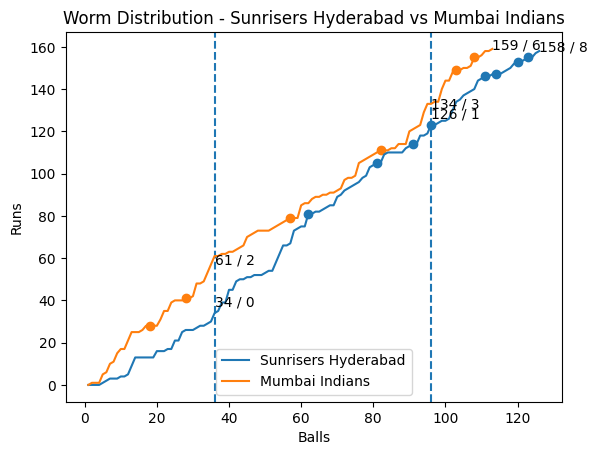

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

ddf=pd.read_csv("deliveries.csv")

def visualization(ddf,matchid):
  df=ddf[ddf.match_id==matchid]

  df1=df[df.inning==1].reset_index(drop=True)
  df2=df[df.inning==2].reset_index(drop=True)
  team1=list(df1["batting_team"].unique())[0]
  team2=list(df2["batting_team"].unique())[0]
  df1["cum_runs"]=0
  df2["cum_runs"]=0
  runscount=0
  for i in range(len(df1)):
    runscount+=df1["total_runs"][i]
    df1["cum_runs"][i]=runscount
  runscount=0
  for i in range(len(df2)):
    runscount+=df2["total_runs"][i]
    df2["cum_runs"][i]=runscount

  ppdf1= df1[df1.over<=6]
  middf1=df1[(df1.over>6) & (df1.over<=16)]

  ppdf2= df2[df2.over<=6]
  middf2=df2[(df2.over>6) & (df2.over<=16)]
  dfwki1=df1[~df1.player_dismissed.isna()]
  dfwki2=df2[~df2.player_dismissed.isna()]

  ppruns1=list(ppdf1["cum_runs"])[-1]
  midruns1=list(middf1["cum_runs"])[-1]
  ppruns2=list(ppdf2["cum_runs"])[-1]
  midruns2=list(middf2["cum_runs"])[-1]
  ppw1=0
  midw1=0
  ppw2=0
  midw2=0

  for i in list(dfwki1.index):
    if i<=35:
      ppw1+=1
      print(ppw1)
    elif i<=95:
      midw1=ppw1+1

    else:
      pass
  for i in list(dfwki2.index):
    if i<=35:
      ppw2+=1
    elif i<=95:
      midw2=ppw2+1
    else:
      pass


  endtext = str(list(df1["cum_runs"])[-1])+" / "+str(len(dfwki1))
  endtext2 = str(list(df2["cum_runs"])[-1])+" / "+str(len(dfwki2))
  pptext1=str(list(ppdf1["cum_runs"])[-1])+" / "+str(ppw1)
  midtext1=str(list(middf1["cum_runs"])[-1])+" / "+str(midw1)
  pptext2=str(list(ppdf2["cum_runs"])[-1])+" / "+str(ppw2)
  midtext2=str(list(middf2["cum_runs"])[-1])+" / "+str(midw2)


  plt.scatter(list(dfwki1.index),list(dfwki1["cum_runs"]))
  plt.scatter(list(dfwki2.index),list(dfwki2["cum_runs"]))
  plt.axvline(36,ls="--")
  plt.axvline(96,ls="--")
  plt.plot([i+1 for i in range(len(df1))],list(df1["cum_runs"]),label=team1)
  plt.plot([i+1 for i in range(len(df2))],list(df2["cum_runs"]),label=team2)
  plt.text(len(ppdf1),list(ppdf1["cum_runs"])[-1]+3,pptext1)
  if len(df1)>95:
    plt.text(96,list(middf1["cum_runs"])[-1],midtext1)
  plt.text(36,list(ppdf2["cum_runs"])[-1]-4,pptext2)
  if len(df2)>95:
    plt.text(96,list(middf2["cum_runs"])[-1]-3,midtext2)
  plt.title(f"Worm Distribution - {team1} vs {team2}")
  plt.xlabel("Balls")
  plt.ylabel("Runs")
  plt.text(len(df1),list(df1["cum_runs"])[-1],endtext)
  plt.text(len(df2),list(df2["cum_runs"])[-1],endtext2)

  plt.legend()
  plt.show()
visualization(ddf,10)